# Artefact 1 — Geography Verification

**Claim:** The Nimbus-C2 Saab extension loads the Saab-supplied Boreal Passage canvas (`Boreal_passage_coordinates.csv`) losslessly into Nimbus-C2 dataclasses, and the resulting geometry matches the supplied map (`the-boreal-passage-map.svg`).

**What this demonstrates:**
- The adapter preserves all 12 installations and 8 terrain polygons from the source CSV.
- Coordinate transformations (CSV y-down → engine y-up) are explicit and documented.
- The extension imports `nimbus_c2` as an unmodified dependency.

**What this does NOT demonstrate:**
- Correctness of the underlying geography (fictitious scenario).
- Tactical realism or operational fitness.
- Any claim about production readiness.

**Reproducibility:** this notebook is deterministic. Running it twice produces byte-identical figures.

In [1]:
# SPDX-FileCopyrightText: 2026 Team Ruby
# SPDX-License-Identifier: MIT

import csv
from importlib import resources

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt

from nimbus_saab_ext import load_boreal_geography

# Load via the extension adapter
geo = load_boreal_geography()

# Independent verification: re-read the raw CSV directly
csv_path = resources.files("nimbus_saab_ext") / "data" / "Boreal_passage_coordinates.csv"
with csv_path.open("r", encoding="utf-8") as f:
    raw_rows = list(csv.DictReader(f))

raw_locations = [r for r in raw_rows if r["record_type"] == "location"]
raw_terrain   = [r for r in raw_rows if r["record_type"] == "terrain"]

print(f"Raw CSV:  {len(raw_locations):2d} locations, {len(raw_terrain):2d} terrain features")
print(f"Adapter:  {len(geo.locations):2d} locations, {len(geo.terrain):2d} terrain features")
print()
print("Sides represented:", sorted({f.side for f in geo.locations}))
print("Location subtypes:", sorted({f.subtype for f in geo.locations}))
print("Terrain subtypes: ", sorted({f.subtype for f in geo.terrain}))
print()
print("North air bases: ", [b.feature_name for b in geo.north_air_bases])
print("South air bases: ", [b.feature_name for b in geo.south_air_bases])
print(f"North capital:   {geo.north_capital.feature_name} at ({geo.north_capital.x_km:.1f}, {geo.north_capital.y_km:.1f})")
print(f"South capital:   {geo.south_capital.feature_name} at ({geo.south_capital.x_km:.1f}, {geo.south_capital.y_km:.1f})")


Raw CSV:  12 locations,  8 terrain features
Adapter:  12 locations,  8 terrain features

Sides represented: ['north', 'south']
Location subtypes: ['air_base', 'capital', 'major_city']
Terrain subtypes:  ['island', 'mainland', 'peninsula']

North air bases:  ['Northern Vanguard Base', 'Highridge Command', 'Boreal Watch Post']
South air bases:  ['Firewatch Station', 'Southern Redoubt', 'Spear Point Base']
North capital:   Arktholm (Capital X) at (418.3, 1205.0)
South capital:   Meridia (Capital Y) at (1225.0, 91.7)


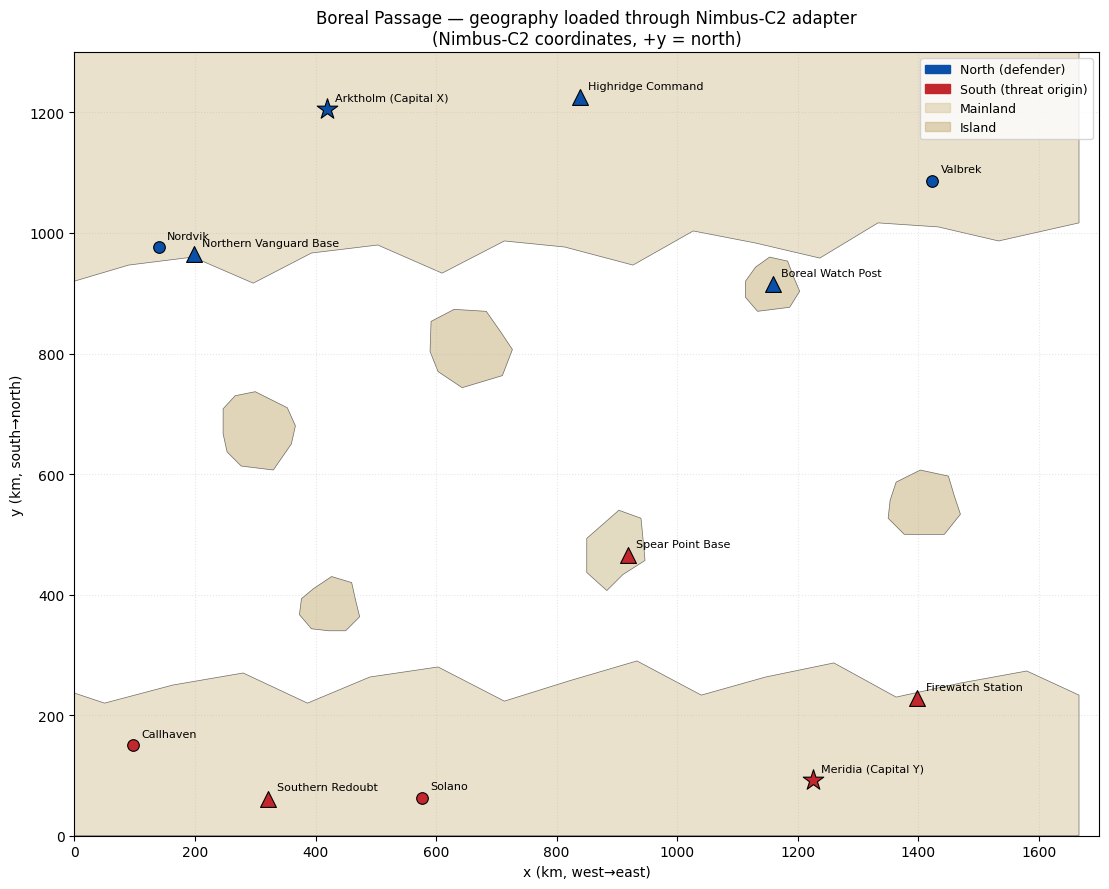


Figure saved: results/figures/01_boreal_geography.png


In [2]:
# Visualize geography in Nimbus-C2 coordinates (+y = north)
# SVG uses +y = south; the adapter flips on ingest.

fig, ax = plt.subplots(figsize=(13, 9))

terrain_colors = {
    "mainland":  "#d9c9a3",
    "island":    "#c7b280",
    "peninsula": "#cdbf8e",
}

# Draw terrain polygons
for feat in geo.terrain:
    color = terrain_colors.get(feat.subtype, "#cccccc")
    if feat.polygon_km:
        patch = mpatches.Polygon(
            feat.polygon_km, closed=True,
            facecolor=color, edgecolor="black",
            linewidth=0.5, alpha=0.55,
        )
        ax.add_patch(patch)

# Draw locations coloured by side
side_colors = {"north": "#0a4fa8", "south": "#c1272d"}
subtype_markers = {
    "capital":    ("*", 240),
    "air_base":   ("^", 130),
    "major_city": ("o",  70),
}

for feat in geo.locations:
    color = side_colors.get(feat.side, "#666666")
    marker, size = subtype_markers.get(feat.subtype, ("s", 80))
    ax.scatter(feat.x_km, feat.y_km, c=color, s=size,
               marker=marker, zorder=4,
               edgecolor="black", linewidth=0.8)
    ax.annotate(feat.feature_name, (feat.x_km, feat.y_km),
                xytext=(6, 6), textcoords="offset points",
                fontsize=8, zorder=5)

ax.set_xlabel("x (km, west→east)")
ax.set_ylabel("y (km, south→north)")
ax.set_title("Boreal Passage — geography loaded through Nimbus-C2 adapter\n"
             "(Nimbus-C2 coordinates, +y = north)")
ax.set_aspect("equal")
ax.set_xlim(0, 1700)
ax.set_ylim(0, 1300)
ax.grid(True, linestyle=":", alpha=0.3)

legend_handles = [
    mpatches.Patch(color=side_colors["north"], label="North (defender)"),
    mpatches.Patch(color=side_colors["south"], label="South (threat origin)"),
    mpatches.Patch(color=terrain_colors["mainland"], label="Mainland", alpha=0.55),
    mpatches.Patch(color=terrain_colors["island"],   label="Island",   alpha=0.55),
]
ax.legend(handles=legend_handles, loc="upper right", fontsize=9)

fig.tight_layout()
fig.savefig("../results/figures/01_boreal_geography.png", dpi=120, bbox_inches="tight")
plt.show()
print("\nFigure saved: results/figures/01_boreal_geography.png")


## Verification summary

| Source | Locations | Terrain features |
|---|---|---|
| Raw CSV          | 12 | 8 |
| Adapter view     | 12 | 8 |

**Lossless load confirmed.** Every row in the Saab-supplied CSV is accounted for in the adapter's representation.

**Coordinate convention (explicit):** the CSV uses image-space y-down (Arktholm at `y ≈ 95`, Meridia at `y ≈ 1208`). The adapter flips to Nimbus-C2 convention y-up via `y_nimbus = Y_EXTENT_KM - y_csv` (where `Y_EXTENT_KM = 1300`). After the flip, Arktholm sits in the north (high y), Meridia in the south (low y), matching tactical intent.

**Independent verification:** the raw CSV row counts are computed directly from the source file using the standard library `csv` module, not via the adapter. The match is therefore a claim about the adapter's fidelity, not about itself.

**Figure saved to** `results/figures/01_boreal_geography.png`. Visual comparison with the Saab-supplied `data/saab/the-boreal-passage-map.svg` is left to the reviewer.

Proceed to [Notebook 2 — Pipeline determinism](./02_pipeline_determinism.ipynb).